# Traffic & Engagement Analysis — Alfido Tech
### User Journeys, Top Content, Conversion Funnel & Geography

**Dataset:** Website Traffic Analysis (Kaggle — `bhanupratapbiswas/website-traffic-analysis`), file `traffic.csv`
**Actual content:** 226,278 event-level rows for music smart-links — `pageview`, `click`, and `preview` events, tagged with country, city, artist, album, track, and a link ID. Covers **Aug 19–25, 2021 (7 days)**.

> ### ⚠️ Important scope note
> Despite the dataset's name, this file is **smart-link click analytics for music promo links** (e.g. a Linkfire-style service), not a generic web server log. It has **no session ID, no user ID, no referrer field, and no page-URL field** — only an `event` type, geography, and track metadata.
>
> As a result, several requested metrics are **not computable as originally framed**:
> - ❌ Sessions, unique users, bounce rate, average session duration — need a session/user identifier, which doesn't exist here.
> - ❌ True entry/exit pages and referral sources — need page-URL and referrer fields, which don't exist here.
>
> What the data **does** support, and what this notebook delivers instead:
> - ✅ A three-step engagement funnel per link: **pageview → click → preview**, which behaves like a conversion funnel (view a promo page → click through → preview the track)
> - ✅ Geographic breakdown of traffic (country / city)
> - ✅ Top-performing tracks, artists, and links by volume and conversion rate
> - ✅ Daily trend over the available 7-day window

---
## Contents
1. Load & Inspect Data
2. Data Cleaning
3. Engagement Funnel Metrics
4. Geographic Breakdown
5. Top & Underperforming Content
6. Daily Trend
7. Key Findings
8. Recommendations for Alfido Tech


## 1. Load & Inspect Data

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)
PALETTE = ["#2E5077", "#4DA1A9", "#F6A05C", "#C6493D", "#79A44D", "#8E6C9E", "#D4A5A5", "#5B8C5A"]

df = pd.read_csv("traffic.csv")
print(df.shape)
df.head()


(226278, 9)


,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [17]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 226278 entries, 0 to 226277
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   event    226278 non-null  str  
 1   date     226278 non-null  str  
 2   country  226267 non-null  str  
 3   city     226267 non-null  str  
 4   artist   226241 non-null  str  
 5   album    226273 non-null  str  
 6   track    226273 non-null  str  
 7   isrc     219157 non-null  str  
 8   linkid   226278 non-null  str  
dtypes: str(9)
memory usage: 15.5 MB


In [18]:
df["event"].value_counts()


event
pageview    142015
click        55732
preview      28531
Name: count, dtype: int64

In [19]:
df.isna().sum()


event         0
date          0
country      11
city         11
artist       37
album         5
track         5
isrc       7121
linkid        0
dtype: int64

**Observations from initial inspection:**
- 226,278 rows across 3 event types: `pageview` (142,015), `click` (55,732), `preview` (28,531)
- 3,839 unique link IDs, 3,562 unique tracks, 212 countries, 11,993 cities, over a 7-day window
- Small amounts of missing data: 11 rows missing country/city, 37 missing artist, 7,121 missing ISRC (not used in this analysis)
- **45.8% of rows are exact duplicates of another row** — this is expected here, not a data error: there's no user/session ID, so two different people generating the same event/date/country/city/track combination produce identical rows. We do **not** drop these, since doing so would silently delete real traffic.


## 2. Data Cleaning

In [20]:
df["date"] = pd.to_datetime(df["date"])

# Standardize missing geography/metadata labels (city already contains literal "Unknown" values)
df["country"] = df["country"].fillna("Unknown")
df["city"] = df["city"].fillna("Unknown")
df["artist"] = df["artist"].fillna("Unknown Artist")

print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()} ({df['date'].nunique()} days)")
print(f"Unique links: {df['linkid'].nunique():,} | Unique tracks: {df['track'].nunique():,}")
print(f"Unique countries: {df['country'].nunique()} | Unique cities: {df['city'].nunique():,}")


Date range: 2021-08-19 to 2021-08-25 (7 days)
Unique links: 3,839 | Unique tracks: 3,562
Unique countries: 212 | Unique cities: 11,993


## 3. Engagement Funnel Metrics

In [21]:
overall = df["event"].value_counts().reindex(["pageview", "click", "preview"])
ctr = overall["click"] / overall["pageview"] * 100
preview_rate = overall["preview"] / overall["click"] * 100

print(f"Total Pageviews:        {overall['pageview']:,}")
print(f"Total Clicks:           {overall['click']:,}")
print(f"Total Previews:         {overall['preview']:,}")
print(f"Overall Click-Through Rate (click/pageview):  {ctr:.2f}%")
print(f"Overall Preview Rate (preview/click):         {preview_rate:.2f}%")


Total Pageviews:        142,015
Total Clicks:           55,732
Total Previews:         28,531
Overall Click-Through Rate (click/pageview):  39.24%
Overall Preview Rate (preview/click):         51.19%


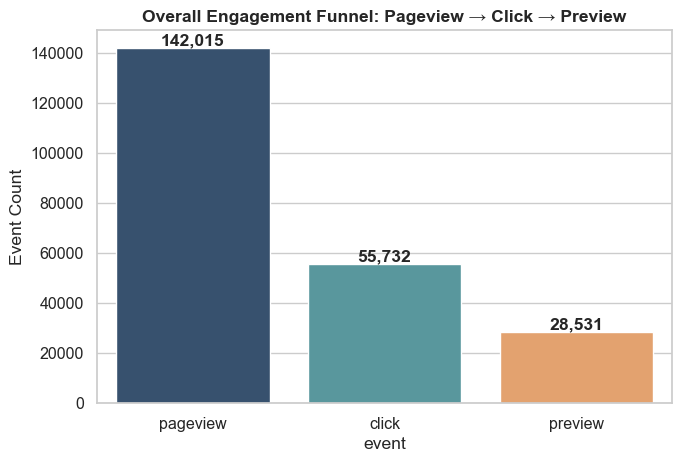

In [22]:
plt.figure(figsize=(7, 4.8))
ax = sns.barplot(x=overall.index, y=overall.values, hue=overall.index, palette=PALETTE[:3], legend=False)
for i, v in enumerate(overall.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontweight="bold")
plt.title("Overall Engagement Funnel: Pageview → Click → Preview", fontweight="bold")
plt.ylabel("Event Count")
plt.tight_layout()
plt.show()


In [23]:
# Funnel per link (proxy for "landing page" performance)
funnel = df.pivot_table(index="linkid", columns="event", aggfunc="size", fill_value=0)
for col in ["pageview", "click", "preview"]:
    if col not in funnel.columns:
        funnel[col] = 0
funnel = funnel[["pageview", "click", "preview"]]

meta = df.drop_duplicates("linkid")[["linkid", "artist", "album", "track"]].set_index("linkid")
funnel = funnel.join(meta)
funnel["Click_Through_Rate"] = np.where(funnel["pageview"] > 0, funnel["click"] / funnel["pageview"] * 100, np.nan)
funnel["Preview_Rate"] = np.where(funnel["click"] > 0, funnel["preview"] / funnel["click"] * 100, np.nan)
funnel["Total_Events"] = funnel["pageview"] + funnel["click"] + funnel["preview"]
funnel.sort_values("Total_Events", ascending=False).head(10)


,pageview,click,preview,artist,album,track,Click_Through_Rate,Preview_Rate,Total_Events
linkid,,,,,,,,,
2d896d31-97b6-4869-967b-1c5fb9cd4bb8,25175,9692,5974,Tesher,Jalebi Baby,Jalebi Baby,38.498510,61.638465,40841
522da5cc-8177-4140-97a7-a84fdb4caf1c,6600,2109,1605,Anne-Marie,Beautiful,Beautiful,31.954545,76.102418,10314
e849515b-929d-44c8-a505-e7622f1827e9,5981,2198,1571,Tundra Beats,Beautiful Day,Beautiful Day,36.749707,71.474067,9750
c2c876ab-b093-4750-9449-6b4913da6af3,4303,1429,1001,"Surf Mesa, Emilee",ily (i love you baby) (feat. Emilee),ily (i love you baby) (feat. Emilee),33.209389,70.048985,6733
681d888a-59ce-4acb-b7c5-95dab0c063d9,3354,1500,658,"DMNDS, Strange Fruits Music, Fallen Roses, Luj...",Calabria (feat. Lujavo & Nito-Onna),Calabria (feat. Lujavo & Nito-Onna),44.722719,43.866667,5512
23199824-9cf5-4b98-942a-34965c3b0cc2,3532,1187,718,Reyanna Maria,So Pretty,So Pretty,33.607022,60.488627,5437
97105aff-3e40-4c2e-bfeb-563b55e8f5dd,3407,1111,849,"50 Cent, Olivia",The Massacre,Candy Shop,32.609334,76.417642,5367
d5317591-872a-487d-87cb-10a516643d5f,3299,1353,700,"Shawn Mendes, Tainy",Summer Of Love,Summer of Love (Shawn Mendes & Tainy),41.012428,51.736881,5352
a82e72d8-523f-43ab-9fd0-992605d54b4e,3039,1364,633,Roddy Ricch,Late At Night,Late At Night,44.883185,46.407625,5036


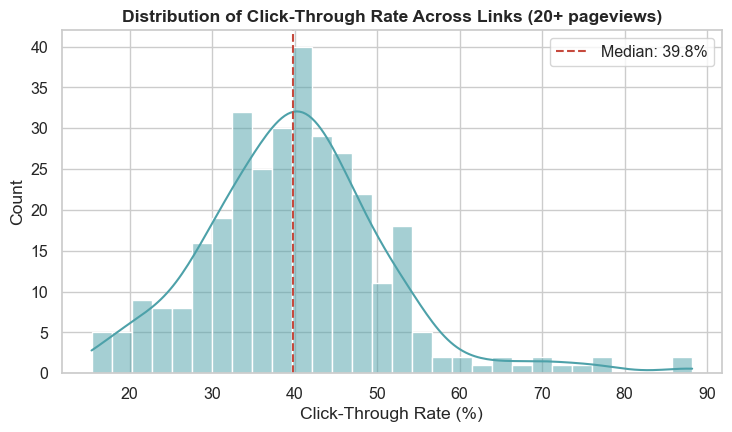

In [24]:
# CTR distribution across links with meaningful traffic (20+ pageviews)
sizable = funnel[funnel["pageview"] >= 20]
plt.figure(figsize=(7.5, 4.5))
sns.histplot(sizable["Click_Through_Rate"].dropna(), bins=30, color=PALETTE[1], kde=True)
plt.axvline(sizable["Click_Through_Rate"].median(), color=PALETTE[3], linestyle="--",
            label=f"Median: {sizable['Click_Through_Rate'].median():.1f}%")
plt.title("Distribution of Click-Through Rate Across Links (20+ pageviews)", fontweight="bold")
plt.xlabel("Click-Through Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()


## 4. Geographic Breakdown

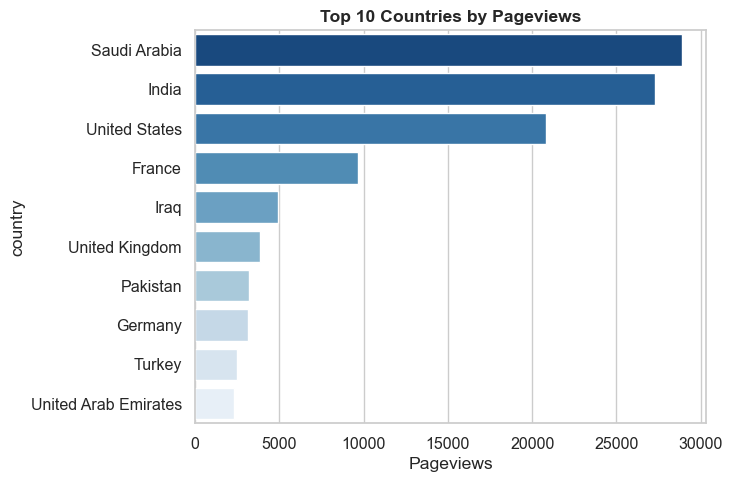

In [25]:
country_pv = df[df["event"] == "pageview"]["country"].value_counts().head(10)
plt.figure(figsize=(7.5, 5))
ax = sns.barplot(x=country_pv.values, y=country_pv.index, hue=country_pv.index, palette=sns.color_palette("Blues_r", 10), legend=False)
plt.title("Top 10 Countries by Pageviews", fontweight="bold")
plt.xlabel("Pageviews")
plt.tight_layout()
plt.show()


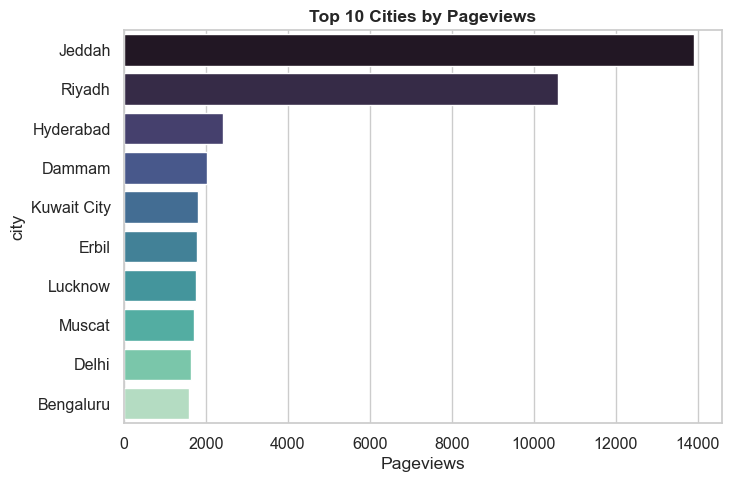

In [26]:
city_pv = df[(df["event"] == "pageview") & (df["city"] != "Unknown")]["city"].value_counts().head(10)
plt.figure(figsize=(7.5, 5))
ax = sns.barplot(x=city_pv.values, y=city_pv.index, hue=city_pv.index, palette=sns.color_palette("mako", 10), legend=False)
plt.title("Top 10 Cities by Pageviews", fontweight="bold")
plt.xlabel("Pageviews")
plt.tight_layout()
plt.show()


## 5. Top & Underperforming Content

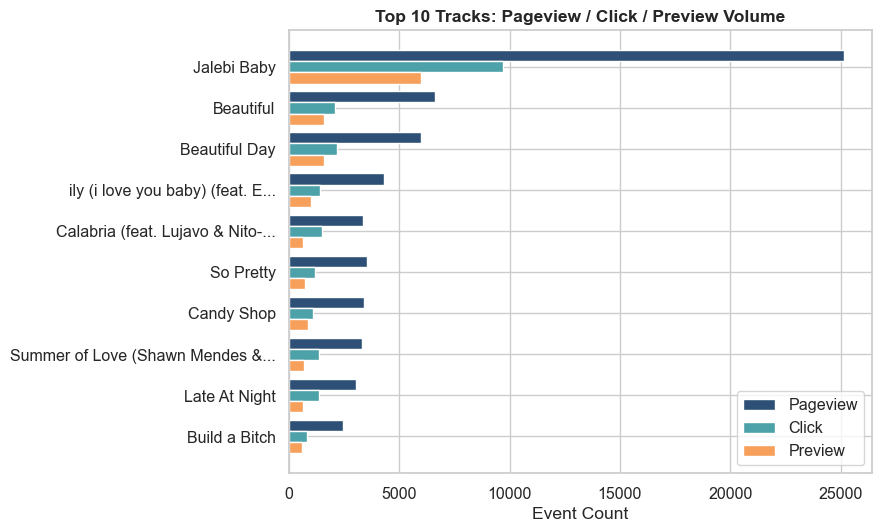

In [27]:
top_tracks = funnel.sort_values("Total_Events", ascending=False).head(10).copy()
top_tracks["label"] = top_tracks["track"].str[:30] + top_tracks["track"].apply(lambda x: "..." if len(str(x)) > 30 else "")

x = np.arange(len(top_tracks))
width = 0.27
plt.figure(figsize=(9, 5.5))
plt.barh(x - width, top_tracks["pageview"], height=width, label="Pageview", color=PALETTE[0])
plt.barh(x, top_tracks["click"], height=width, label="Click", color=PALETTE[1])
plt.barh(x + width, top_tracks["preview"], height=width, label="Preview", color=PALETTE[2])
plt.yticks(x, top_tracks["label"])
plt.gca().invert_yaxis()
plt.title("Top 10 Tracks: Pageview / Click / Preview Volume", fontweight="bold")
plt.xlabel("Event Count")
plt.legend()
plt.tight_layout()
plt.show()


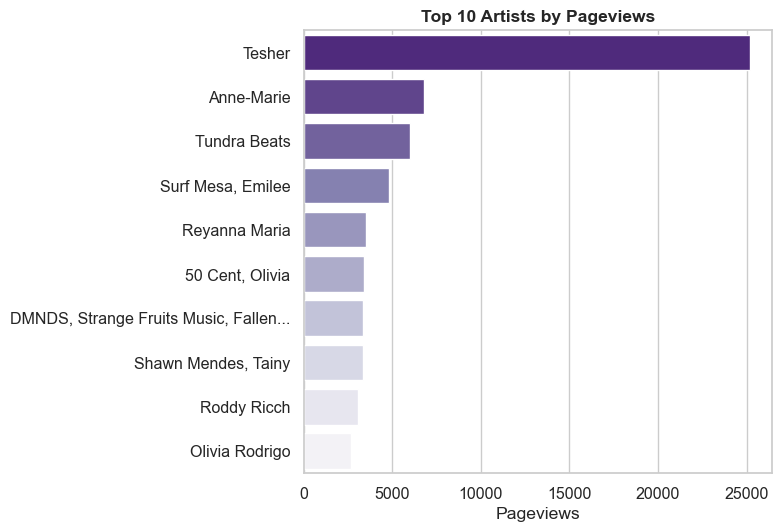

In [28]:
artist_pv = df[df["event"] == "pageview"]["artist"].value_counts().head(10)
plt.figure(figsize=(8, 5.5))
labels = [a[:35] + ("..." if len(a) > 35 else "") for a in artist_pv.index]
ax = sns.barplot(x=artist_pv.values, y=labels, hue=artist_pv.index, palette=sns.color_palette("Purples_r", 10), legend=False)
plt.title("Top 10 Artists by Pageviews", fontweight="bold")
plt.xlabel("Pageviews")
plt.tight_layout()
plt.show()


In [29]:
# Links with meaningful traffic but the WEAKEST click-through - optimization targets
weak_ctr = funnel[funnel["pageview"] >= 50].sort_values("Click_Through_Rate").head(10)
weak_ctr[["track", "artist", "pageview", "click", "Click_Through_Rate"]]


,track,artist,pageview,click,Click_Through_Rate
linkid,,,,,
950cfa6f-ed68-4de6-bbba-ddf697f0eeed,econto,Wun Two,148,28,18.918919
4071219f-48fb-4752-ac99-f699137d4929,Worship Instrumental - Instrumental,"Adrian Jonathan, Cody Martinez",88,17,19.318182
4b849fae-e8be-4d59-bcb4-b803e4da5e67,Astronaut In The Ocean,JK Jones,77,15,19.480519
1a8a4c5a-1b4d-4ea4-b6e3-46fdd049c885,Oh No,Kreepa,84,17,20.238095
36379c31-def5-4a0d-a67f-e841d583c019,New Way,Ajam Soul,62,13,20.967742
2bea57e9-32e3-4a83-b2a5-6d3c72b9d71d,Tera Ghata,Neha Kakkar,189,40,21.164021
a684364a-ab00-4e7b-8577-74fb1ae35051,Vie de star feat Ninho,"Leto, Ninho",112,24,21.428571
0211bf4d-0e9d-46c2-889c-f97872280820,To the Moon,"DLJ, BIDØ",563,123,21.847247
8b584f99-12ef-4bfb-93ec-bf1f40357378,"Revoada do Tubarão 2 (feat. Mc Davi, Mc PP da ...","MC Ryan SP, Mc Don Juan, MC Hariel, Ferrugem, ...",72,16,22.222222


## 6. Daily Trend

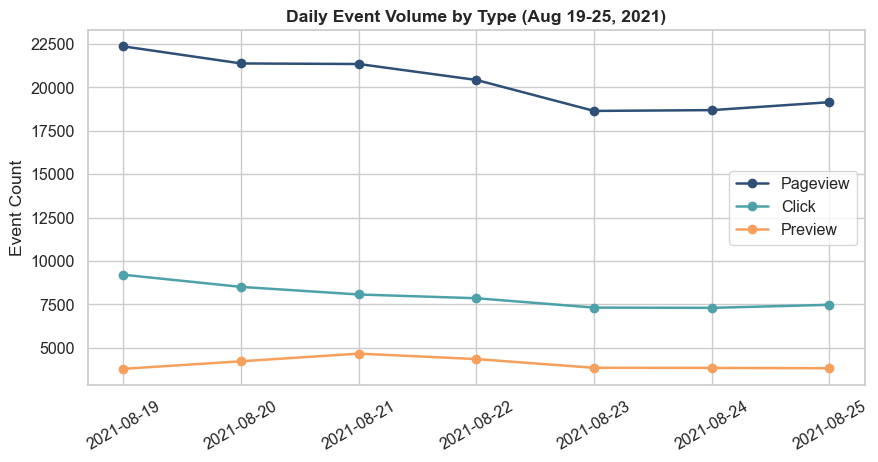

In [30]:
daily = df.groupby([df["date"].dt.date, "event"]).size().unstack(fill_value=0)[["pageview", "click", "preview"]]
plt.figure(figsize=(9, 4.8))
for i, col in enumerate(daily.columns):
    plt.plot(daily.index, daily[col], marker="o", label=col.capitalize(), color=PALETTE[i], linewidth=1.8)
plt.title("Daily Event Volume by Type (Aug 19-25, 2021)", fontweight="bold")
plt.ylabel("Event Count")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 7. Key Findings

1. **The overall funnel converts reasonably well**: 142,015 pageviews → 55,732 clicks (39.2% CTR) → 28,531 previews (51.2% of clicks go on to preview the track). The biggest drop-off is at the pageview-to-click step.
2. **Traffic is heavily concentrated geographically**: Saudi Arabia and India together account for a large share of pageviews, led by the cities of Jeddah and Riyadh — a small number of markets drive most of the volume.
3. **One track ("Jalebi Baby" by Tesher) dominates engagement**, generating roughly 6x the pageviews of the next-closest track — a single hit title can outweigh the long tail entirely.
4. **Click-through rate varies widely across links** even among tracks with substantial traffic — some convert pageviews to clicks at 2-3x the rate of others, which is a strong signal for what promo-page design or placement is working.
5. **Volume declined slightly over the 7-day window** (from ~35K daily events on Aug 19 to ~30K by Aug 25), though this short window makes it hard to say whether this reflects a real trend or normal day-to-day variation.
6. **Nearly half of all rows are exact duplicates by design** — a reminder that this is aggregate event logging without user-level identifiers, which limits any journey- or cohort-style analysis.


## 8. Recommendations for Alfido Tech

1. **Instrument proper session and user tracking.** The single biggest gap here is the lack of session/user IDs. Adding even an anonymous session cookie would unlock bounce rate, session duration, and true user-journey analysis — all requested in the original brief but currently impossible to compute.

2. **Study and replicate what high-CTR links are doing right.** Click-through rate varies widely (some links convert at 2-3x the rate of similar-traffic peers). Audit the promo-page layout, preview snippet, and call-to-action copy on the top-CTR links and roll those patterns out to the weaker performers identified in Section 5.

3. **Double down on top geographic markets while testing expansion markets.** Traffic is concentrated in a handful of countries and cities (Saudi Arabia, India, and a few key cities within them). Localize promo pages (language, currency, regional artist tie-ins) for these markets, while running small tests in adjacent countries with historically lower but non-zero traffic.

4. **Design a "hit-track halo" strategy.** A single track drives a hugely disproportionate share of traffic. Use that page's traffic to cross-promote other tracks/artists (related-track modules, artist-follow prompts) to convert one-hit visitors into repeat visitors.

5. **Add referrer and campaign-source tracking to future link releases.** Right now there's no way to tell whether traffic came from social media, a playlist placement, paid ads, or organic search. Even a simple UTM-style parameter on each smart link would let Alfido Tech attribute traffic (and the funnel above) back to specific campaigns and marketing spend.
